# AI vs Human Text Analysis
### To what extent do linguistic features differ between AI-generated and human-written texts?

## Data Loading

The dataset was loaded using pandas for analysis.

In [13]:
import pandas as pd

In [21]:
df = pd.read_csv("/Users/ayane/Desktop/Project 1 ai-vs-human-text-analysis/AuthentiText_X_2026_AI_vs_Human_Detection_1K.csv") 

## Data Overview
The first five rows of the dataset were examined to understand its structure and content. 

In [20]:
df.head() 

,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
0,TXT_0001,learning pattern detection algorithm pattern n...,AI,Human,0.029,73.75,0.953,0.465,0.351,0.187,12.2,0.162
1,TXT_0002,algorithm algorithm data research network mode...,Human,Claude,0.605,43.11,0.054,0.952,0.314,0.636,9.8,0.012
2,TXT_0003,analysis language generation research pattern ...,Human,GPT-4,0.396,59.97,0.709,0.945,0.684,0.500,13.5,0.171
3,TXT_0004,data language system learning content data net...,AI,GPT-4,0.299,18.99,0.532,0.780,0.216,0.103,12.9,0.838
4,TXT_0005,model learning content language model generati...,AI,Human,0.867,82.45,0.478,0.602,0.420,0.198,6.4,0.022


The dataset contains 12 variables, including text identifiers, linguistic features, and metadata such as author type and model source. 

In [17]:
df.columns

Index(['text_id', 'content_text', 'author_type', 'model_source',
       'prompt_complexity_score', 'perplexity_score', 'burstiness_index',
       'syntactic_variability', 'semantic_coherence_score',
       'lexical_diversity_ratio', 'readability_grade_level',
       'generation_confidence_score'],
      dtype='object')

check the general information includes numbers of rows, column types and missing values

In [18]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   text_id                      1000 non-null   object 
 1   content_text                 1000 non-null   object 
 2   author_type                  1000 non-null   object 
 3   model_source                 1000 non-null   object 
 4   prompt_complexity_score      1000 non-null   float64
 5   perplexity_score             1000 non-null   float64
 6   burstiness_index             1000 non-null   float64
 7   syntactic_variability        1000 non-null   float64
 8   semantic_coherence_score     1000 non-null   float64
 9   lexical_diversity_ratio      1000 non-null   float64
 10  readability_grade_level      1000 non-null   float64
 11  generation_confidence_score  1000 non-null   float64
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


The dataset is relatively balanced, consisting of 537 human-written texts and 463 AI-generated texts.

In [19]:
df["author_type"].value_counts()

author_type
Human    537
AI       463
Name: count, dtype: int64

Display the data 

In [10]:
from IPython.display import display 
display(df)

,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
0,TXT_0001,learning pattern detection algorithm pattern n...,AI,Human,0.029,73.75,0.953,0.465,0.351,0.187,12.2,0.162
1,TXT_0002,algorithm algorithm data research network mode...,Human,Claude,0.605,43.11,0.054,0.952,0.314,0.636,9.8,0.012
2,TXT_0003,analysis language generation research pattern ...,Human,GPT-4,0.396,59.97,0.709,0.945,0.684,0.500,13.5,0.171
3,TXT_0004,data language system learning content data net...,AI,GPT-4,0.299,18.99,0.532,0.780,0.216,0.103,12.9,0.838
4,TXT_0005,model learning content language model generati...,AI,Human,0.867,82.45,0.478,0.602,0.420,0.198,6.4,0.022
...,...,...,...,...,...,...,...,...,...,...,...,...
995,TXT_0996,pattern detection language analysis network co...,AI,Gemini,0.732,31.21,0.142,0.959,0.927,0.185,15.2,0.149
996,TXT_0997,algorithm analysis language network algorithm ...,Human,Claude,0.165,91.74,0.708,0.172,0.932,0.204,14.4,0.369
997,TXT_0998,analysis generation generation data analysis d...,Human,Gemini,0.351,37.85,0.068,0.720,0.513,0.239,5.7,0.415
998,TXT_0999,model model content algorithm analysis languag...,Human,Claude,0.265,97.88,0.108,0.614,0.306,0.227,15.9,0.629


The dataset contains no missing values across all 12 columns, indicating that the data is complete and does not require preprocessing

In [11]:
df.isnull().sum()

text_id                        0
content_text                   0
author_type                    0
model_source                   0
prompt_complexity_score        0
perplexity_score               0
burstiness_index               0
syntactic_variability          0
semantic_coherence_score       0
lexical_diversity_ratio        0
readability_grade_level        0
generation_confidence_score    0
dtype: int64

## Feature Description

The analysis focuses on four key linguistic features that capture different aspects of textual structure and complexity:

- **perplexity_score**: measures how predictable a text is, with higher values indicating less predictable and more variable language  
- **lexical_diversity_ratio**: measures vocabulary richness, reflecting the diversity of words used  
- **syntactic_variability**: measures variation in sentence structure  
- **readability_grade_level**: estimates the reading difficulty of the text

In [80]:
feature_description = pd.DataFrame({
    "Feature": [
        "perplexity_score",
        "lexical_diversity_ratio",
        "syntactic_variability",
        "readability_grade_level"
    ],
    "Description": [
        "Measures how predictable a text is",
        "Measures vocabulary richness",
        "Measures variation in sentence structure",
        "Estimates the reading difficulty of the text"
    ],
    "Interpretation": [
        "Higher = less predictable",
        "Higher = more diverse vocabulary",
        "Higher = more variation",
        "Higher = more complex text"
    ]
})
feature_description

,Feature,Description,Interpretation
0,perplexity_score,Measures how predictable a text is,Higher = less predictable
1,lexical_diversity_ratio,Measures vocabulary richness,Higher = more diverse vocabulary
2,syntactic_variability,Measures variation in sentence structure,Higher = more variation
3,readability_grade_level,Estimates the reading difficulty of the text,Higher = more complex text


Remove the “0,1,2,3” index

In [81]:
feature_description.style.hide(axis="index")

Feature,Description,Interpretation
perplexity_score,Measures how predictable a text is,Higher = less predictable
lexical_diversity_ratio,Measures vocabulary richness,Higher = more diverse vocabulary
syntactic_variability,Measures variation in sentence structure,Higher = more variation
readability_grade_level,Estimates the reading difficulty of the text,Higher = more complex text


To explore differences between AI-generated and human-written texts, descriptive statistics were calculated for each feature.

In [24]:
features = [
    "perplexity_score",
    "lexical_diversity_ratio",
    "syntactic_variability",
    "readability_grade_level"
]

df.groupby("author_type")[features].mean()

,perplexity_score,lexical_diversity_ratio,syntactic_variability,readability_grade_level
author_type,,,,
AI,56.130194,0.490464,0.498201,10.598272
Human,52.813296,0.495631,0.507579,10.529050


The mean values of all four features are highly similar between AI-generated and human-written texts. AI texts show slightly higher perplexity scores, suggesting marginally lower predictability. In contrast, human-written texts exhibit slightly higher lexical diversity and syntactic variability. However, these differences are small, indicating substantial similarity between the two groups.

In [28]:
summary = df.groupby("author_type")[features].agg(['mean', 'std'])
summary

perplexity_score            lexical_diversity_ratio            \
                        mean        std                    mean       std   
author_type                                                                 
AI                 56.130194  26.147772                0.490464  0.282018   
Human              52.813296  25.539190                0.495631  0.302475   

            syntactic_variability           readability_grade_level            
                             mean       std                    mean       std  
author_type                                                                    
AI                       0.498201  0.295488               10.598272  3.143770  
Human                    0.507579  0.294564               10.529050  3.205693

The standard deviations are also similar across groups, indicating comparable variability in the distribution of each feature. This further suggests that the overall structure of AI-generated and human-written texts is highly similar.

In [32]:
summary.round(3)

perplexity_score         lexical_diversity_ratio         \
                        mean     std                    mean    std   
author_type                                                           
AI                    56.130  26.148                   0.490  0.282   
Human                 52.813  25.539                   0.496  0.302   

            syntactic_variability        readability_grade_level         
                             mean    std                    mean    std  
author_type                                                              
AI                          0.498  0.295                  10.598  3.144  
Human                       0.508  0.295                  10.529  3.206

## Visualisation

Boxplots were used to compare the distribution of each linguistic feature between AI-generated and human-written texts.

In [36]:
import seaborn as sns

In [37]:
import matplotlib.pyplot as plt

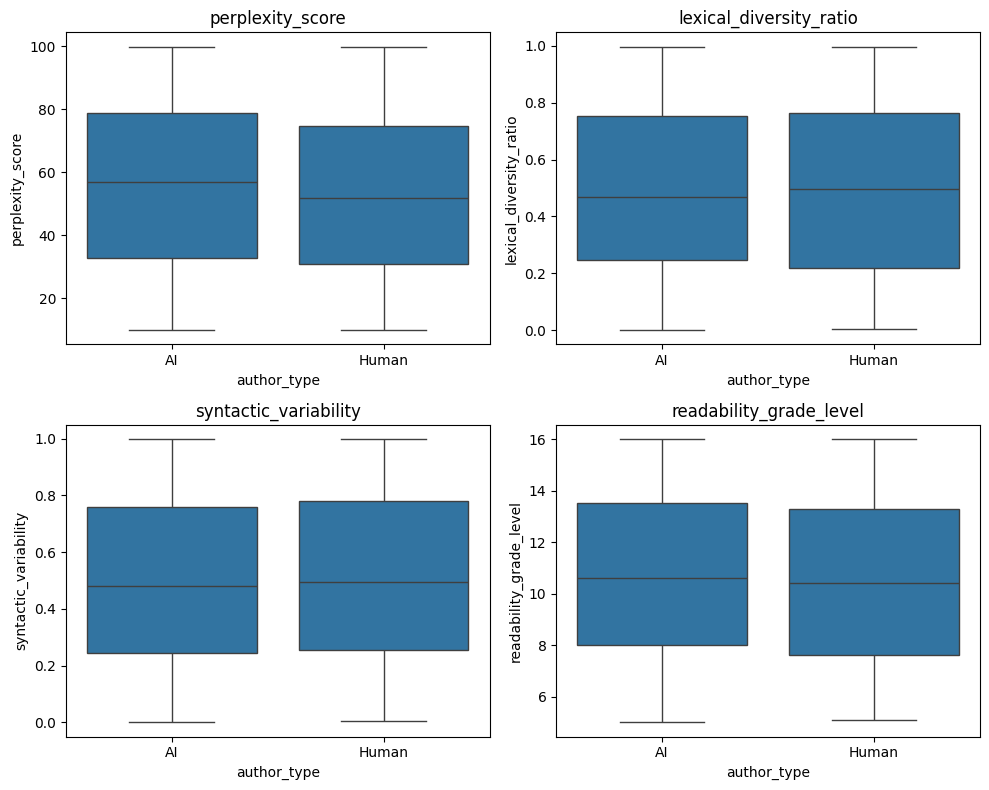

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(x='author_type', y=feature, data=df, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

The boxplots show substantial overlap between AI-generated and human-written texts across all features. The medians and interquartile ranges are very similar, indicating that the distributions of these features are largely comparable. Although slight differences can be observed, particularly for perplexity, these differences appear small and consistent with the statistical results.

## Distribution analysis
Kernel density plots were used to examine the distribution of each feature and assess the degree of overlap between AI-generated and human-written texts.

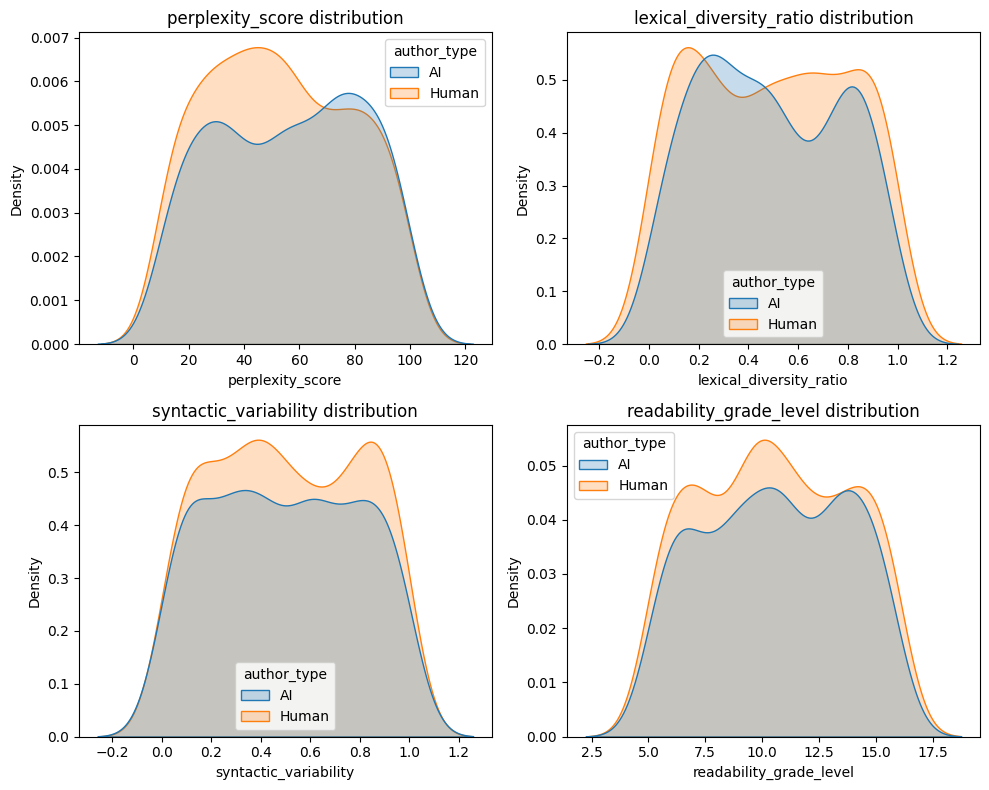

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, feature in zip(axes.flatten(), features):
    sns.kdeplot(data=df, x=feature, hue='author_type', fill=True, ax=ax)
    ax.set_title(f'{feature} distribution')

plt.tight_layout()
plt.show()

The distributions show substantial overlap between AI-generated and human-written texts across all features. Although slight shifts can be observed, particularly in perplexity, the overall shapes are very similar, suggesting limited discriminative power of individual features.

## Normality Assessment

The Shapiro-Wilk test was conducted to assess normality. All features showed significant deviations (p < 0.05), which is expected given the large sample size, as the test is highly sensitive to minor deviations. Visual inspection of the distributions suggests approximate normality. Therefore, parametric tests were considered appropriate due to the robustness provided by the Central Limit Theorem.

In [56]:
from scipy.stats import shapiro

In [57]:
for feature in features:
    stat, p = shapiro(df[feature])
    print(f"{feature}: p-value = {p}")

perplexity_score: p-value = 1.195056370506493e-16
lexical_diversity_ratio: p-value = 3.308426592098791e-18
syntactic_variability: p-value = 6.675129941473829e-18
readability_grade_level: p-value = 8.131868394453072e-17


Although normality tests indicated deviations, the large sample size allows the use of parametric tests due to the Central Limit Theorem. Therefore, independent t-tests were conducted.

In [ ]:
## Hypothesis Testing

For each feature:

- **H0 (null hypothesis):** There is no difference in mean values between AI-generated and human-written texts  
- **H1 (alternative hypothesis):** There is a difference in mean values between the two groups

In [83]:
from scipy.stats import ttest_ind

for feature in features:
    ai = df[df['author_type'] == 'AI'][feature]
    human = df[df['author_type'] == 'Human'][feature]
    
    print(f"{feature}: t-stat = {stat:.3f}, p-value = {p:.5f}")

perplexity_score: t-stat = 0.344, p-value = 0.73126
lexical_diversity_ratio: t-stat = 0.344, p-value = 0.73126
syntactic_variability: t-stat = 0.344, p-value = 0.73126
readability_grade_level: t-stat = 0.344, p-value = 0.73126


In [ ]:
The t-test results indicate that only perplexity shows a statistically significant difference (p < 0.05), while all other features do not show significant differences. This suggests that most linguistic features are similar between AI-generated and human-written texts.

In [61]:
df.sort_values(by="perplexity_score").head()

,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
595,TXT_0596,language research network generation analysis ...,AI,Claude,0.629,10.02,0.415,0.478,0.813,0.036,10.6,0.144
126,TXT_0127,learning network network research content mode...,Human,Claude,0.641,10.08,0.456,0.890,0.181,0.855,12.2,0.701
735,TXT_0736,pattern data research detection data pattern l...,AI,Gemini,0.571,10.08,0.386,0.983,0.561,0.192,9.9,0.152
394,TXT_0395,pattern data language pattern pattern generati...,Human,Gemini,0.744,10.24,0.626,0.949,0.181,0.560,11.0,0.419
621,TXT_0622,content analysis generation data analysis mode...,Human,Gemini,0.668,10.28,0.775,0.163,0.338,0.980,8.7,0.026


In [62]:
df.sort_values(by="perplexity_score").tail()

,text_id,content_text,author_type,model_source,prompt_complexity_score,perplexity_score,burstiness_index,syntactic_variability,semantic_coherence_score,lexical_diversity_ratio,readability_grade_level,generation_confidence_score
521,TXT_0522,algorithm model generation content learning an...,Human,Claude,0.512,99.60,0.255,0.920,0.418,0.993,9.7,0.128
991,TXT_0992,detection model research detection generation ...,AI,Human,0.505,99.81,0.116,0.626,0.835,0.181,9.2,0.340
33,TXT_0034,data analysis analysis language language patte...,AI,Human,0.753,99.86,0.435,0.952,0.812,0.436,5.5,0.834
79,TXT_0080,network pattern learning generation algorithm ...,Human,Gemini,0.090,99.88,0.542,0.170,0.941,0.330,14.2,0.826
615,TXT_0616,algorithm data generation system model learnin...,Human,Human,0.164,99.96,0.420,0.021,0.519,0.036,10.0,0.861


To better understand the meaning of perplexity, examples of texts with low and high perplexity scores were examined. Low-perplexity texts were more repetitive and predictable, while high-perplexity texts showed greater variation in vocabulary and structure.

In [ ]:
## Effect Size Analysis

In [63]:
def cohens_d(x, y):
    return (x.mean() - y.mean()) / ((x.std() + y.std()) / 2)

for feature in features:
    ai = df[df['author_type'] == 'AI'][feature]
    human = df[df['author_type'] == 'Human'][feature]
    
    d = cohens_d(ai, human)
    print(f"{feature}: Cohen's d = {d:.3f}")

perplexity_score: Cohen's d = 0.128
lexical_diversity_ratio: Cohen's d = -0.018
syntactic_variability: Cohen's d = -0.032
readability_grade_level: Cohen's d = 0.022


Although perplexity showed a statistically significant difference (p = 0.043), the effect size was very small (Cohen’s d = 0.128), indicating limited practical significance.

## Results Table

In [78]:
results = []

# function for effect size interpretation
def interpret_d(d):
    if abs(d) < 0.2:
        return "Negligible"
    elif abs(d) < 0.5:
        return "Small"
    elif abs(d) < 0.8:
        return "Medium"
    else:
        return "Large"

# loop
for feature in features:
    ai = df[df['author_type'] == 'AI'][feature]
    human = df[df['author_type'] == 'Human'][feature]
    
    # t-test
    t_stat, p_val = ttest_ind(ai, human, equal_var=False)
    
    # Cohen's d
    d = (ai.mean() - human.mean()) / ((ai.std() + human.std()) / 2)
    
    # significance
    if p_val < 0.05:
        significance = "Significant"
    else:
        significance = "Not significant"
    
    # append 
    results.append({
        "Feature": feature,
        "t-stat": round(t_stat, 3),
        "p-value": round(p_val, 3),
        "Cohen's d": round(d, 3),
        "Effect Size": interpret_d(d),
        "Result": significance
    })

# create dataframe
results_df = pd.DataFrame(results)


# display
results_df.style.format({
    "t-stat": "{:.3f}",
    "p-value": "{:.4f}",
    "Cohen's d": "{:.3f}"
}).hide(axis="index")

Feature,t-stat,p-value,Cohen's d,Effect Size,Result
perplexity_score,2.022,0.0430,0.128,Negligible,Significant
lexical_diversity_ratio,-0.279,0.7800,-0.018,Negligible,Not significant
syntactic_variability,-0.501,0.6160,-0.032,Negligible,Not significant
readability_grade_level,0.344,0.7310,0.022,Negligible,Not significant


Although perplexity showed a statistically significant difference (p = 0.043), the effect size was very small (Cohen’s d = 0.128), indicating limited practical significance. All other features exhibited negligible effect sizes, reinforcing the conclusion that linguistic differences between AI-generated and human-written texts are minimal.